In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [87]:
# Load data
customers      = pd.read_csv('data/source/olist_customers_dataset.csv')
geoloc         = pd.read_csv('data/source/olist_geolocation_dataset.csv')
order_items    = pd.read_csv('data/source/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/source/olist_order_payments_dataset.csv')
order_reviews  = pd.read_csv('data/source/olist_order_reviews_dataset.csv')
orders         = pd.read_csv('data/source/olist_orders_dataset.csv')
products       = pd.read_csv('data/source/olist_products_dataset.csv')
sellers        = pd.read_csv('data/source/olist_sellers_dataset.csv')
categories     = pd.read_csv('data/source/product_category_name_translation.csv')

In [88]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [89]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [90]:
customers.shape

(99441, 5)

In [91]:
customers['customer_id'].nunique()

99441

In [92]:
customers['customer_unique_id'].nunique()

96096

In [93]:
customers['customer_city'].unique()

array(['franca', 'sao bernardo do campo', 'sao paulo', ...,
       'monte bonito', 'sao rafael', 'eugenio de castro'], dtype=object)

In [94]:
customers['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [95]:
customers.duplicated().sum()

0

In [96]:
customers.drop(columns = 'customer_unique_id',inplace = True)

In [97]:
geoloc.sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
984046,96910,-29.342638,-52.976897,segredo,RS
806213,75680,-18.145514,-48.563291,corumbaiba,GO
953467,92410,-29.901677,-51.163812,canoas,RS
862419,83322,-25.454297,-49.177774,pinhais,PR
82710,4224,-23.596249,-46.595460,sao paulo,SP


In [98]:
geoloc.duplicated().sum()

261831

In [99]:
geoloc = geoloc.drop_duplicates()

In [100]:
geoloc.duplicated().sum()

0

In [101]:
geoloc.shape

(738332, 5)

In [102]:
geoloc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


In [103]:
geoloc['geolocation_city'].nunique()

8011

In [173]:
geoloc[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']].duplicated().sum()

18178

In [174]:
geoloc_clean = geoloc.groupby("geolocation_zip_code_prefix").agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"
}).reset_index()

In [177]:
geoloc_clean[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']].duplicated().sum()

0

In [175]:
geoloc.sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
926662,89211,-26.330109,-48.843040,joinville,SC
193837,7916,-23.278116,-46.754927,francisco morato,SP
124205,5386,-23.565652,-46.760459,sao paulo,SP
800738,74885,-16.722313,-49.208224,goiania,GO
456156,22735,-22.923938,-43.360454,rio de janeiro,RJ


In [104]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [105]:
order_items.duplicated().sum()

0

In [106]:
order_items.shape

(112650, 7)

In [107]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


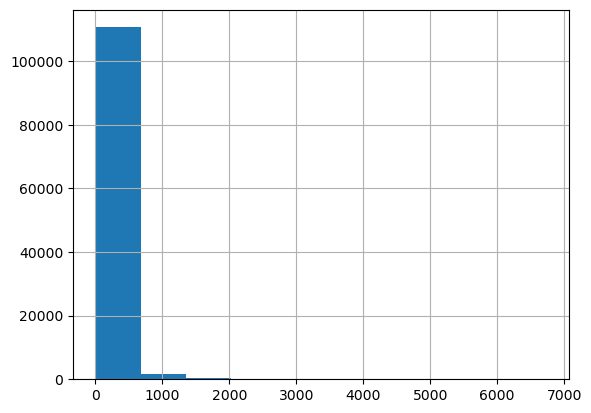

In [108]:
order_items['price'].hist()
plt.show()

In [109]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [110]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'] , errors = 'coerce')

In [111]:
order_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

In [112]:
order_items[['price','freight_value']].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


In [113]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [114]:
order_payments['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [115]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [116]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [117]:
order_payments.duplicated().sum()

0

In [118]:
order_payments.shape

(103886, 5)

In [119]:
for col in order_payments.columns:
    print(f"{col}: {order_payments[col].nunique()} unique values")


order_id: 99440 unique values
payment_sequential: 29 unique values
payment_type: 5 unique values
payment_installments: 24 unique values
payment_value: 29077 unique values


In [120]:
order_payments['order_id'].duplicated().sum()

4446

In [121]:
order_reviews.sample(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
57990,ea5f7240e4efbdfa126abf4a8e9988f6,3842b7ad02b831026ee377ddef334206,5,NaN,"Ótima loja, bons produtos.",2017-08-26 00:00:00,2017-08-28 21:28:16
72427,9b2bd8d59117f1afb5be1c95556e75be,666a6228ea2363c308924bc929101d7f,5,NaN,NaN,2017-09-19 00:00:00,2017-09-19 17:02:01
69949,d59ac9c72b8606e09805e909173c5560,10857948637314508e05a14dfd8328b9,5,NaN,NaN,2017-04-08 00:00:00,2017-04-09 12:44:59
31568,329db4fc6468d59a3765a3caa9b9fbe7,4093a63e6c3fa6b277e0fe4b6347ed49,5,NaN,NaN,2018-01-06 00:00:00,2018-01-07 21:41:31
8258,1e545dbafe14661a72fbd6d0b90007ff,9cfee74db86dd5914edd7fdfd39559de,4,NaN,Produto entregue. 1 dos produtos só funciona n...,2018-01-23 00:00:00,2018-01-25 17:13:43
9314,9b32eced9364125509656959cea1b2bc,85eef2d342b0de363c45c1bc324729c5,3,pena que ficou pequena,"teria que ter a medida certa e a cor, porque n...",2018-05-12 00:00:00,2018-05-15 15:40:59
4932,3c260965ce42c18e6908b38c28e2cdd7,49f879aa078787ff9ca5e831515407b9,5,NaN,NaN,2017-09-12 00:00:00,2017-09-12 16:43:34
24023,c940e3e726d0ccbab9aeedf5dcfc3188,db582aca3fc2d44e76fa63eb576032c5,5,NaN,Produto chegou bem antes do prazo e é exatamen...,2017-05-13 00:00:00,2017-05-15 16:35:54
91373,a14b389c81fe6cd29b0a1294d0da6354,c3c0e95fc6035316212f1b4e2c7bce3d,4,NaN,NaN,2018-07-10 00:00:00,2018-07-18 16:28:41
33559,46e1c4ef65541cd55e2fef669aa4344d,7a2ff12a85b39e51a3ee9972fdc5eb78,5,NaN,Tiveram problema na entrega que me preocupou m...,2017-06-22 00:00:00,2017-06-27 15:33:16


In [122]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [123]:
order_reviews.duplicated().sum()

0

In [124]:
order_reviews.drop(columns = 'review_comment_title',inplace = True)

In [125]:
order_reviews['review_comment_message'].fillna('NO COMMENT',inplace = True)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_16468\452140024.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_reviews['review_comment_message'].fillna('NO COMMENT',inplace = True)


In [126]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'], errors = 'coerce')

In [127]:
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'], errors = 'coerce')

In [128]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_message   99224 non-null  object        
 4   review_creation_date     99224 non-null  datetime64[ns]
 5   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 4.5+ MB


In [129]:
orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
9702,8347204e1ae41b2ad30899fa41a0a889,67e68659e454ee97821ddb96f4b91c11,unavailable,2017-03-03 23:49:03,2017-03-04 01:33:07,NaN,NaN,2017-03-22 00:00:00
71125,af5248d345341f797de31954e0d3d2f4,5b116028bd1f354477b49032b5c31766,delivered,2018-04-08 14:41:41,2018-04-09 17:13:40,2018-04-10 20:24:27,2018-04-20 20:27:39,2018-05-07 00:00:00
26657,d758b90e0bc24cf60e79e90ad8dabc53,c079a535248d520556b7b445ade42db2,delivered,2017-11-15 23:54:40,2017-11-16 00:56:18,2017-11-22 23:43:46,2017-12-02 13:22:20,2017-12-13 00:00:00
8195,6f0a7a4f82b93cb505c3434e16a1d984,6ae108a103903506b207a3168689f13b,delivered,2018-03-29 22:24:34,2018-03-29 22:35:13,2018-04-02 22:13:10,2018-04-12 02:48:45,2018-05-04 00:00:00
11771,673242a6057d4287cb24379d405cf5ac,0d7da1d5507a67dbb512b53744e775e9,delivered,2017-07-15 14:31:13,2017-07-15 14:43:29,2017-07-18 20:12:44,2017-07-28 18:32:36,2017-08-10 00:00:00


In [130]:
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [131]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [132]:
orders.shape

(99441, 8)

In [133]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [134]:
columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in columns:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')


In [135]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [136]:
orders.shape

(99441, 8)

In [137]:
orders.duplicated().sum()

0

In [138]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [139]:
# check timeline validation 
timeline_error = orders[
    (orders['order_approved_at'] < orders['order_purchase_timestamp']) |
    (orders['order_delivered_carrier_date'] < orders['order_approved_at']) |
    (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date'])
]

In [140]:
timeline_error.shape

(1382, 8)

In [141]:
timeline_error.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
91849,174a7e09ba51eac7b816bf33d20dfe21,2a0fdf25de2d2485bcc958576f5d48ea,delivered,2018-04-20 17:23:30,2018-04-24 19:17:21,2018-04-24 00:26:42,2018-05-11 19:48:53,2018-05-18
74146,f5eda04cf77ec4fc17a1c7a4e8984afb,b884d405e354ad1e5213f72883e4e6ee,delivered,2018-07-02 09:14:07,2018-07-05 16:25:39,2018-07-04 15:16:00,2018-07-14 09:34:39,2018-07-25
58067,374fcc5350e3372ce0d7cab981d7de90,8b5a55f1ca276fe752917ce68a971407,delivered,2018-04-23 10:53:41,2018-04-24 18:34:56,2018-04-24 00:14:49,2018-05-02 17:44:27,2018-05-21
69388,d26e5113b124c2bf24274139cf339a8b,dcd98ca7612d608435bc8233248e8b4c,delivered,2018-07-03 22:27:31,2018-07-05 16:11:40,2018-07-04 10:44:00,2018-07-13 17:12:44,2018-07-26
94942,c6d80ef64d3bab44528b4f5b30b257fb,aa9e7cf1e6114225210fbfd650dc0d3e,delivered,2018-07-03 21:32:18,2018-07-05 16:34:39,2018-07-05 11:41:00,2018-07-12 02:09:39,2018-08-06
41636,b866af202be0692766081310cd4085e1,d1800078046ed2e5ae1b0792b695c56e,delivered,2017-01-27 14:59:17,2017-01-27 15:30:46,2017-02-20 02:32:08,2017-02-15 03:53:46,2017-04-17
59728,04ac671da9c58d9111811d06df6d2513,775c4699698b1ee74e359daff3e7468c,delivered,2018-04-22 19:30:11,2018-04-24 17:51:00,2018-04-24 00:03:29,2018-04-28 15:41:49,2018-05-16
25383,a727355acb88d9b3e6e41fb2e3888a0e,2e3f19e3763da38dd82c6e2e9ff69c98,delivered,2018-07-23 12:58:28,2018-07-28 23:31:01,2018-07-24 15:07:00,2018-07-25 17:35:30,2018-07-31
59931,85f900f229f817bf7e71ed0c9fdb4fa3,03933bd8f668c8444d5307d9d5d171eb,delivered,2018-04-23 17:22:26,2018-04-24 18:23:50,2018-04-24 16:47:49,2018-04-25 18:31:51,2018-05-10
1945,6d5f62b312ef08610aa99b1a365ec10b,2c58296eab043d713ee5fc669f6aba05,delivered,2018-07-05 14:59:58,2018-07-05 16:30:53,2018-07-05 16:08:00,2018-07-10 21:04:13,2018-08-03


In [142]:
# Check what order statuses are behind the nulls
print('order statuses behind nulls')
print('nulls in the order_approved_at')
print(orders[orders['order_approved_at'].isna()]['order_status'].value_counts())
print('nulls in the order_delivered_carrier_date')
print(orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts())
print('nulls in the order_delivered_customer_date')
print(orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts())

order statuses behind nulls
nulls in the order_approved_at
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64
nulls in the order_delivered_carrier_date
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64
nulls in the order_delivered_customer_date
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


# Handling Date Nulls in Orders Dataset (Business)

## Core Principle

**Status-aware handling**:  
Treat nulls as _expected_ for non-completed orders and only flag/investigate nulls that contradict the `order_status`.

This is not a `fillna()` problem — it is a **business process validation problem**.

---

# 1️) Null Classification Strategy

## A) Expected (Business) Nulls
Nulls that are logically correct because the order has not reached that stage.

Examples:
- `order_approved_at` is null for `created` or `canceled`
- `order_delivered_carrier_date` is null for `processing`, `invoiced`
- `order_delivered_customer_date` is null for non-`delivered` orders

---->>> These should be kept as NULL.

---

## B) Invalid Nulls (Data Quality Issues)
Nulls that contradict business logic.

Examples:
- `order_status = delivered` but `order_delivered_customer_date` is NULL
- `order_status IN ('shipped','delivered')` but carrier date is NULL

🚨 These must be **flagged**

---

# 2️⃣ Why Use Data Quality Flags Instead of Filling?

## ❌ Filling Timestamps Is Dangerous

Dates represent **real operational events**:
- Approval
- Shipping
- Delivery

Filling them:
- Alters historical reality
- Distorts KPIs (delivery time, SLA compliance)
- Hides operational issues
- Destroys auditability

---

## ✅ Data Quality Flags Are Better Because They:

- Preserve raw truth
- Maintain auditability
- Enable root cause analysis
- Protect KPI accuracy
- Support governance
- Keep analytical signals intact
- Allow future reprocessing

---


In [143]:
# Create Data Quality Flags
orders['dq_invalid_approval_null'] = (
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
)

orders['dq_invalid_carrier_null'] = (
    (orders['order_status'].isin(['shipped','delivered'])) &
    (orders['order_delivered_carrier_date'].isna())
)

orders['dq_invalid_delivery_null'] = (
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isna())
)

In [144]:
orders.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dq_invalid_approval_null,dq_invalid_carrier_null,dq_invalid_delivery_null
10088,d3ba9cc2ed6bfcb179c9d654974de7f7,a8f2ce0853302c7f6d960aaf99b01a27,delivered,2018-07-22 22:54:11,2018-07-23 12:31:55,2018-07-24 15:44:00,2018-07-27 20:02:11,2018-08-13,False,False,False
9326,45076151b8ea416cffebd82f5013905d,0b5ba46cf03cfbe33cb831c793b78614,delivered,2018-05-20 16:07:46,2018-05-21 08:17:38,2018-05-21 15:10:00,2018-05-30 18:51:34,2018-06-08,False,False,False
36612,26c71804bc6af868d57e6a409f219bfe,cf5b89fd10a74e325c93aa41bed3bd57,delivered,2018-01-03 13:39:43,2018-01-04 05:11:46,2018-01-05 22:43:00,2018-01-10 17:06:58,2018-01-19,False,False,False
80529,483e06611c77dee5a2e4b91b489eb95e,0dc954c9c93860a5d29fee62c27add39,delivered,2017-09-15 15:03:39,2017-09-15 15:15:16,2017-09-21 14:56:28,2017-10-02 18:26:03,2017-10-05,False,False,False
27300,9e4429e3ca6daefcb5a085302eb4d9a9,b47df8baa34b9880117394560bcb04be,delivered,2017-12-08 12:02:45,2017-12-12 03:56:29,2017-12-21 15:58:38,2018-01-06 10:44:20,2018-01-16,False,False,False
14767,da3b31201f3eb351160956d5aa12deb6,3ab5ae0b0b6c2225b6072807d82fac8f,delivered,2018-07-30 12:45:54,2018-07-30 13:04:43,2018-07-30 14:59:00,2018-07-31 20:06:19,2018-08-02,False,False,False
99277,762264d81c3f54fa5e5a4e02b84eb85c,75119e7aa32e3e42fbd019b09af7e7e1,delivered,2017-10-21 22:42:10,2017-10-21 22:56:21,2017-10-24 01:22:55,2017-11-06 21:36:29,2017-11-13,False,False,False
49490,59093e9d4ab91f46ff314e966e4268c1,80242677269637e364586259ccc5558f,shipped,2017-02-10 11:46:44,2017-02-10 11:55:15,2017-02-10 14:30:17,NaT,2017-03-14,False,False,False
58340,ffe146c862ce518ad378598499bf9204,f813294c06241ae2660aa359c74e1d5f,delivered,2018-06-28 21:44:06,2018-06-28 22:10:03,2018-07-03 13:39:00,2018-07-14 07:04:34,2018-07-26,False,False,False
94940,278ce3d59dd06d461a1a4d6703790ae9,25f558b2b9455e35297fc86ded1e0586,delivered,2017-03-11 17:38:51,2017-03-11 17:38:51,2017-03-20 14:42:50,2017-03-27 11:35:57,2017-04-04,False,False,False


In [145]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [146]:
products.shape

(32951, 9)

In [147]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [148]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [149]:
products[[ 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm']].corr()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
product_name_lenght,1.000000,0.098741,0.134321,0.044664,0.080556,-0.016494,0.070741
product_description_lenght,0.098741,1.000000,0.108745,0.062445,0.034849,0.063519,-0.030869
product_photos_qty,0.134321,0.108745,1.000000,0.036539,0.067447,0.004000,0.026319
product_weight_g,0.044664,0.062445,0.036539,1.000000,0.476813,0.563910,0.527597
product_length_cm,0.080556,0.034849,0.067447,0.476813,1.000000,0.204889,0.542409
product_height_cm,-0.016494,0.063519,0.004000,0.563910,0.204889,1.000000,0.313491
product_width_cm,0.070741,-0.030869,0.026319,0.527597,0.542409,0.313491,1.000000


In [150]:
products.nunique()

product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

In [151]:
products.duplicated().sum()

0

In [152]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [153]:
# Fill metadata
products['product_category_name'] = products['product_category_name'].fillna('Uncategorized')
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)

# Recompute derived lengths
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)

# Fill physical attributes with median per category
physical_cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for col in physical_cols:
    products[col] = products.groupby('product_category_name')[col] \
        .transform(lambda x: x.fillna(x.median()))


In [154]:
# check
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [155]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [156]:
sellers.duplicated().sum()

0

In [157]:
sellers.shape

(3095, 4)

In [158]:
sellers.nunique()

seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

In [159]:
sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [160]:
categories.shape

(71, 2)

In [161]:
categories.nunique()

product_category_name            71
product_category_name_english    71
dtype: int64

In [162]:
categories.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [163]:
categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [164]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [165]:
products['product_category_name'].nunique()

74

In [166]:
products['product_category_name'].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio',
       'Uncategorized', 'moveis_sala', 'sinalizacao_e_seguranca',
       'climatizacao', 'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefoni

In [167]:
categories.duplicated().sum()

0

In [168]:

#Merge products + categories
dim_products = products.merge(
    categories,
    on="product_category_name",
    how="left"   # keep all products even if category missing
)

#  Select required columns

dim_products = dim_products[[
    "product_id",
    "product_category_name_english",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_photos_qty"
]]

# Rename columns (clean DWH naming)

dim_products = dim_products.rename(columns={
    "product_category_name_english": "category_name",
    "product_weight_g": "weight_g",
    "product_length_cm": "length_cm",
    "product_height_cm": "height_cm",
    "product_width_cm": "width_cm",
    "product_photos_qty": "photos_qty"
})

# Remove duplicates (safety check)
dim_products = dim_products.drop_duplicates(subset="product_id")

# Handle missing values (optional)


dim_products["category_name"] = dim_products["category_name"].fillna("Unknown")


#  Final check


print(dim_products.shape)
print(dim_products.head())

(32951, 7)
                         product_id   category_name  weight_g  length_cm  \
0  1e9e8ef04dbcff4541ed26657ea517e5       perfumery     225.0       16.0   
1  3aa071139cb16b67ca9e5dea641aaa2f             art    1000.0       30.0   
2  96bd76ec8810374ed1b65e291975717f  sports_leisure     154.0       18.0   
3  cef67bcfe19066a932b7673e239eb23d            baby     371.0       26.0   
4  9dc1a7de274444849c219cff195d0b71      housewares     625.0       20.0   

   height_cm  width_cm  photos_qty  
0       10.0      14.0         1.0  
1       18.0      20.0         1.0  
2        9.0      15.0         1.0  
3        4.0      26.0         1.0  
4       17.0      13.0         4.0  


In [178]:
customers     .to_csv('data/prepared/customers.csv',index= False)
geoloc_clean  .to_csv('data/prepared/geoloc.csv',index= False)
order_items   .to_csv('data/prepared/order_items.csv',index= False)
order_payments.to_csv('data/prepared/order_payments.csv',index= False)
order_reviews .to_csv('data/prepared/order_reviews.csv',index= False)
orders        .to_csv('data/prepared/orders.csv',index= False)
dim_products  .to_csv('data/prepared/products.csv',index= False)
sellers       .to_csv('data/prepared/sellers.csv',index= False)
categories    .to_csv('data/prepared/categories.csv',index= False)